## 1. Environment Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import json

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Paths
DATA_DIR = Path('../../data')
RAW_DIR = DATA_DIR / 'raw'
ANALYSIS_DIR = DATA_DIR / 'analysis'
ANALYSIS_DIR.mkdir(exist_ok=True)

print(f"✓ Environment setup complete")
print(f"✓ Data directory: {DATA_DIR.absolute()}")
print(f"✓ Analysis output: {ANALYSIS_DIR.absolute()}")

✓ Environment setup complete
✓ Data directory: /Users/bibekgupta/Documents/personal/bibek-portfolio/finsight-ai/backend/notebooks/../../data
✓ Analysis output: /Users/bibekgupta/Documents/personal/bibek-portfolio/finsight-ai/backend/notebooks/../../data/analysis


## 2. Data Loading

### 2.1 Load PaySim Dataset

In [2]:
# Find the PaySim CSV file
csv_files = list(RAW_DIR.glob('PS_*.csv'))
if not csv_files:
    raise FileNotFoundError(f"No PaySim CSV found in {RAW_DIR}")

csv_path = csv_files[0]
print(f"📁 Loading dataset: {csv_path.name}")
print(f"📊 File size: {csv_path.stat().st_size / 1024 / 1024:.2f} MB\n")

# Load with pandas (optimized dtypes for memory efficiency)
dtype_map = {
    'step': 'int32',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'object',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'object',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

# Load data
start_time = datetime.now()
df = pd.read_csv(csv_path, dtype=dtype_map)
load_time = (datetime.now() - start_time).total_seconds()

print(f"✓ Dataset loaded in {load_time:.2f} seconds")
print(f"✓ Shape: {df.shape[0]:,} transactions × {df.shape[1]} features")
print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

📁 Loading dataset: PS_20174392719_1491204439457_log.csv
📊 File size: 470.67 MB

✓ Dataset loaded in 3.08 seconds
✓ Shape: 6,362,620 transactions × 11 features
✓ Memory usage: 885.69 MB


### 2.2 Initial Data Profiling

In [3]:
# Basic information
print("="*80)
print("DATASET PROFILE")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Details:")
print("-"*80)
df.info(memory_usage='deep')

print("\n" + "="*80)
print("FIRST 5 TRANSACTIONS")
print("="*80)
df.head()

DATASET PROFILE

Dataset Shape: 6,362,620 rows × 11 columns

Column Details:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), object(2)
memory usage: 885.7 MB

FIRST 5 TRANSACTIONS


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


In [4]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe()

STATISTICAL SUMMARY


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551136e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924048e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 3. Data Quality Report

### 3.1 Missing Values Analysis

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
if missing.sum() == 0:
    print("✓ No missing values detected!")
else:
    print(missing_df[missing_df['Missing_Count'] > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n✓ Duplicate rows: {duplicates:,}")

MISSING VALUES ANALYSIS
✓ No missing values detected!

✓ Duplicate rows: 0


### 3.2 Transaction Type Distribution

TRANSACTION TYPE DISTRIBUTION
            Count  Percentage
type                         
CASH_OUT  2237500       35.17
PAYMENT   2151495       33.81
CASH_IN   1399284       21.99
TRANSFER   532909        8.38
DEBIT       41432        0.65


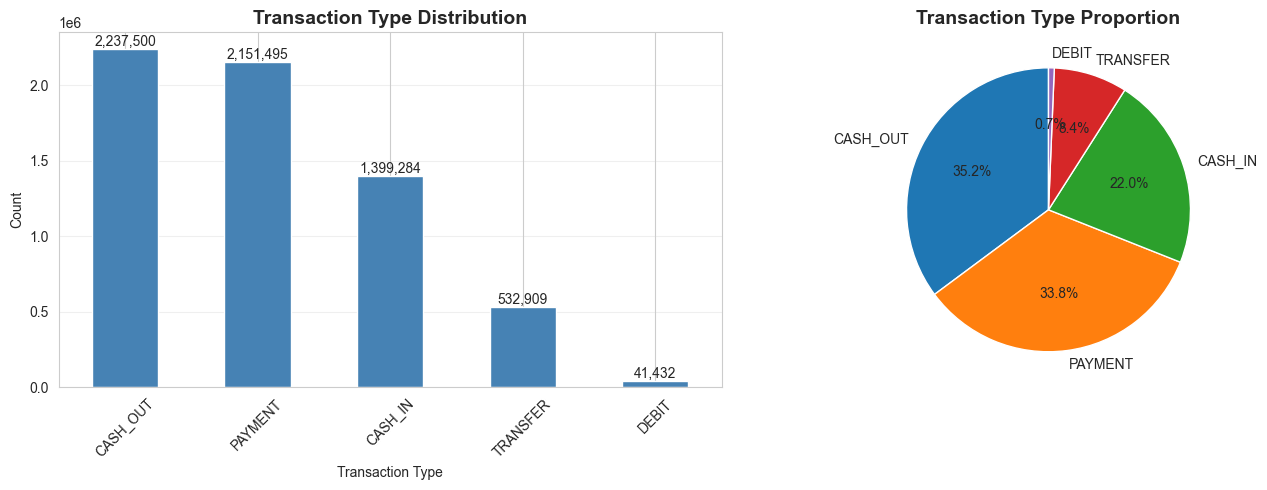


✓ Plot saved to: ../../data/analysis/transaction_type_distribution.png


In [6]:
# Transaction type analysis
type_counts = df['type'].value_counts()
type_pct = (type_counts / len(df) * 100).round(2)

type_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage': type_pct
})

print("="*80)
print("TRANSACTION TYPE DISTRIBUTION")
print("="*80)
print(type_summary)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
type_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Transaction Type Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Transaction Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(type_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom')

# Pie chart
type_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Transaction Type Proportion', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'transaction_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'transaction_type_distribution.png'}")

### 3.3 Fraud Rate Analysis (Critical for Class Imbalance)

FRAUD RATE ANALYSIS
Total Transactions: 6,362,620
Fraudulent: 8,213 (0.1291%)
Legitimate: 6,354,407 (99.8709%)

⚠️  CLASS IMBALANCE RATIO: 1:773

FRAUD RATE BY TRANSACTION TYPE
          Fraud_Count  Total_Count  Fraud_Rate
type                                          
TRANSFER         4097       532909      0.7688
CASH_OUT         4116      2237500      0.1840
CASH_IN             0      1399284      0.0000
DEBIT               0        41432      0.0000
PAYMENT             0      2151495      0.0000


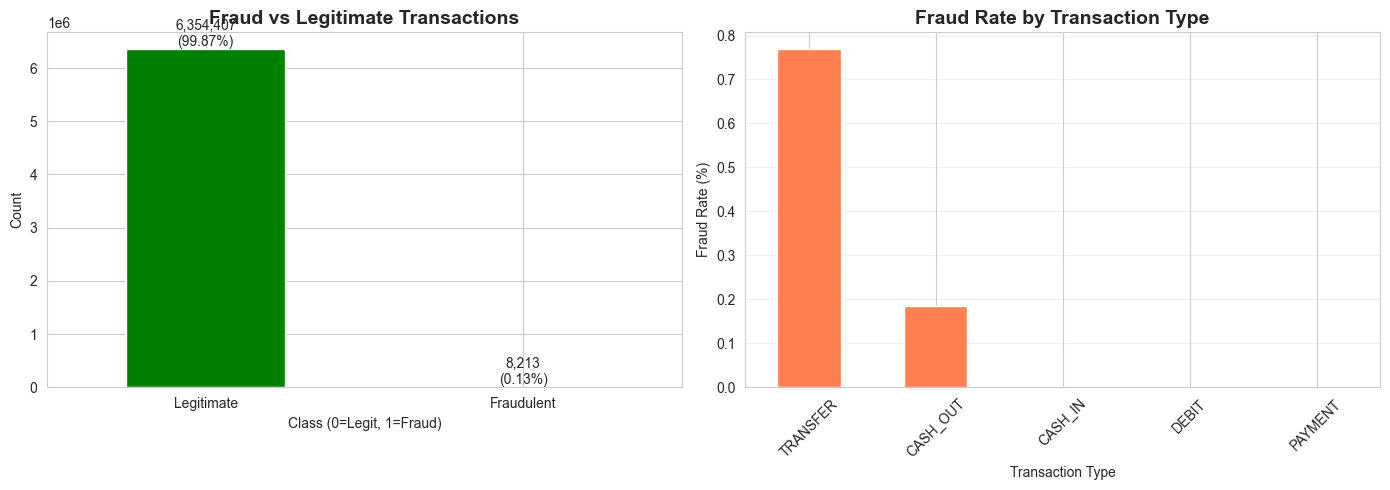


✓ Plot saved to: ../../data/analysis/fraud_rate_analysis.png


In [7]:
# Overall fraud rate
fraud_counts = df['isFraud'].value_counts()
fraud_rate = (df['isFraud'].sum() / len(df) * 100)

print("="*80)
print("FRAUD RATE ANALYSIS")
print("="*80)
print(f"Total Transactions: {len(df):,}")
print(f"Fraudulent: {fraud_counts[1]:,} ({fraud_rate:.4f}%)")
print(f"Legitimate: {fraud_counts[0]:,} ({100-fraud_rate:.4f}%)")
print(f"\n⚠️  CLASS IMBALANCE RATIO: 1:{int(fraud_counts[0]/fraud_counts[1])}")

# Fraud by transaction type
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
fraud_by_type.columns = ['Fraud_Count', 'Total_Count', 'Fraud_Rate']
fraud_by_type['Fraud_Rate'] = (fraud_by_type['Fraud_Rate'] * 100).round(4)
fraud_by_type = fraud_by_type.sort_values('Fraud_Rate', ascending=False)

print("\n" + "="*80)
print("FRAUD RATE BY TRANSACTION TYPE")
print("="*80)
print(fraud_by_type)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall fraud distribution
fraud_counts.plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class (0=Legit, 1=Fraud)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)
for i, v in enumerate(fraud_counts):
    ax1.text(i, v, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', va='bottom')

# Fraud rate by type
fraud_by_type['Fraud_Rate'].plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Fraud Rate by Transaction Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Transaction Type')
ax2.set_ylabel('Fraud Rate (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'fraud_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'fraud_rate_analysis.png'}")

### 3.4 Amount Distribution Analysis

TRANSACTION AMOUNT STATISTICS
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

Amount Range: $0.00 - $92,445,520.00
Median: $74,871.94
99th Percentile: $1,615,979.50


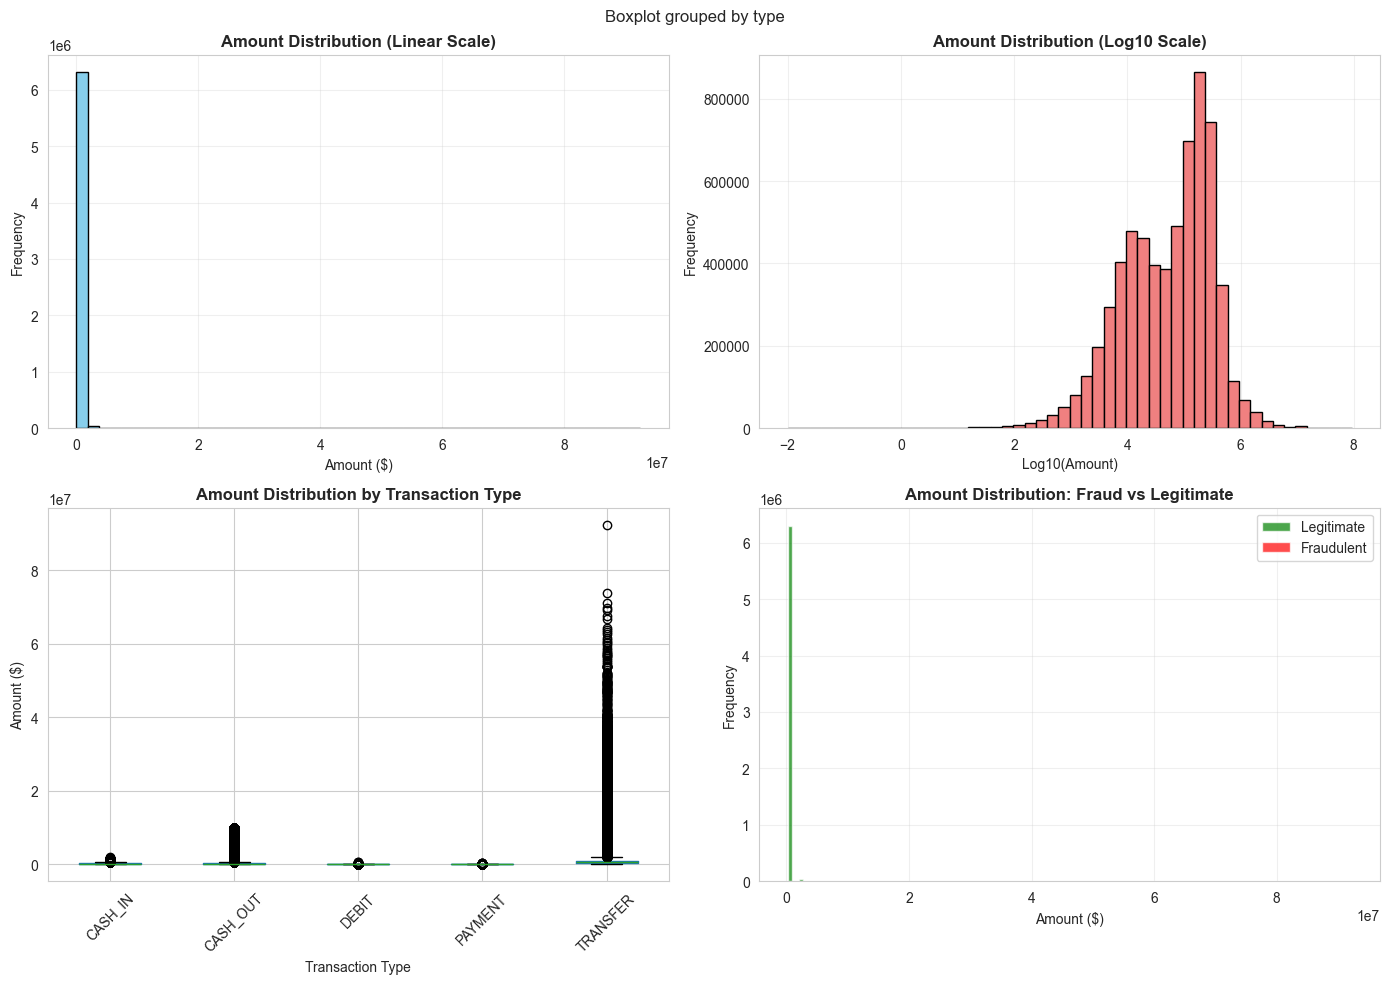


✓ Plot saved to: ../../data/analysis/amount_distribution.png


In [ ]:
# Amount statistics
print("="*80)
print("TRANSACTION AMOUNT STATISTICS")
print("="*80)
print(df['amount'].describe())
print(f"\nAmount Range: ${df['amount'].min():.2f} - ${df['amount'].max():,.2f}")
print(f"Median: ${df['amount'].median():,.2f}")
print(f"99th Percentile: ${df['amount'].quantile(0.99):,.2f}")

# Amount distribution (log scale for better visualization)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regular scale histogram
df['amount'].plot(kind='hist', bins=50, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Amount Distribution (Linear Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Log scale histogram
df[df['amount'] > 0]['amount'].apply(np.log10).plot(
    kind='hist', bins=50, ax=axes[0, 1], color='lightcoral', edgecolor='black'
)
axes[0, 1].set_title('Amount Distribution (Log10 Scale)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log10(Amount)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Box plot by transaction type
df.boxplot(column='amount', by='type', ax=axes[1, 0])
axes[1, 0].set_title('Amount Distribution by Transaction Type', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Transaction Type')
axes[1, 0].set_ylabel('Amount ($)')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Fraud vs Non-Fraud amounts
fraud_amounts = df[df['isFraud'] == 1]['amount']
legit_amounts = df[df['isFraud'] == 0]['amount']

axes[1, 1].hist([legit_amounts, fraud_amounts], bins=50, label=['Legitimate', 'Fraudulent'],
                color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('Amount Distribution: Fraud vs Legitimate', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Amount ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'amount_distribution.png'}")

### 3.5 Temporal Patterns Analysis

TEMPORAL ANALYSIS
Simulation Period: 1 - 743 hours
Total Days: 31
Hours Range: 0-23


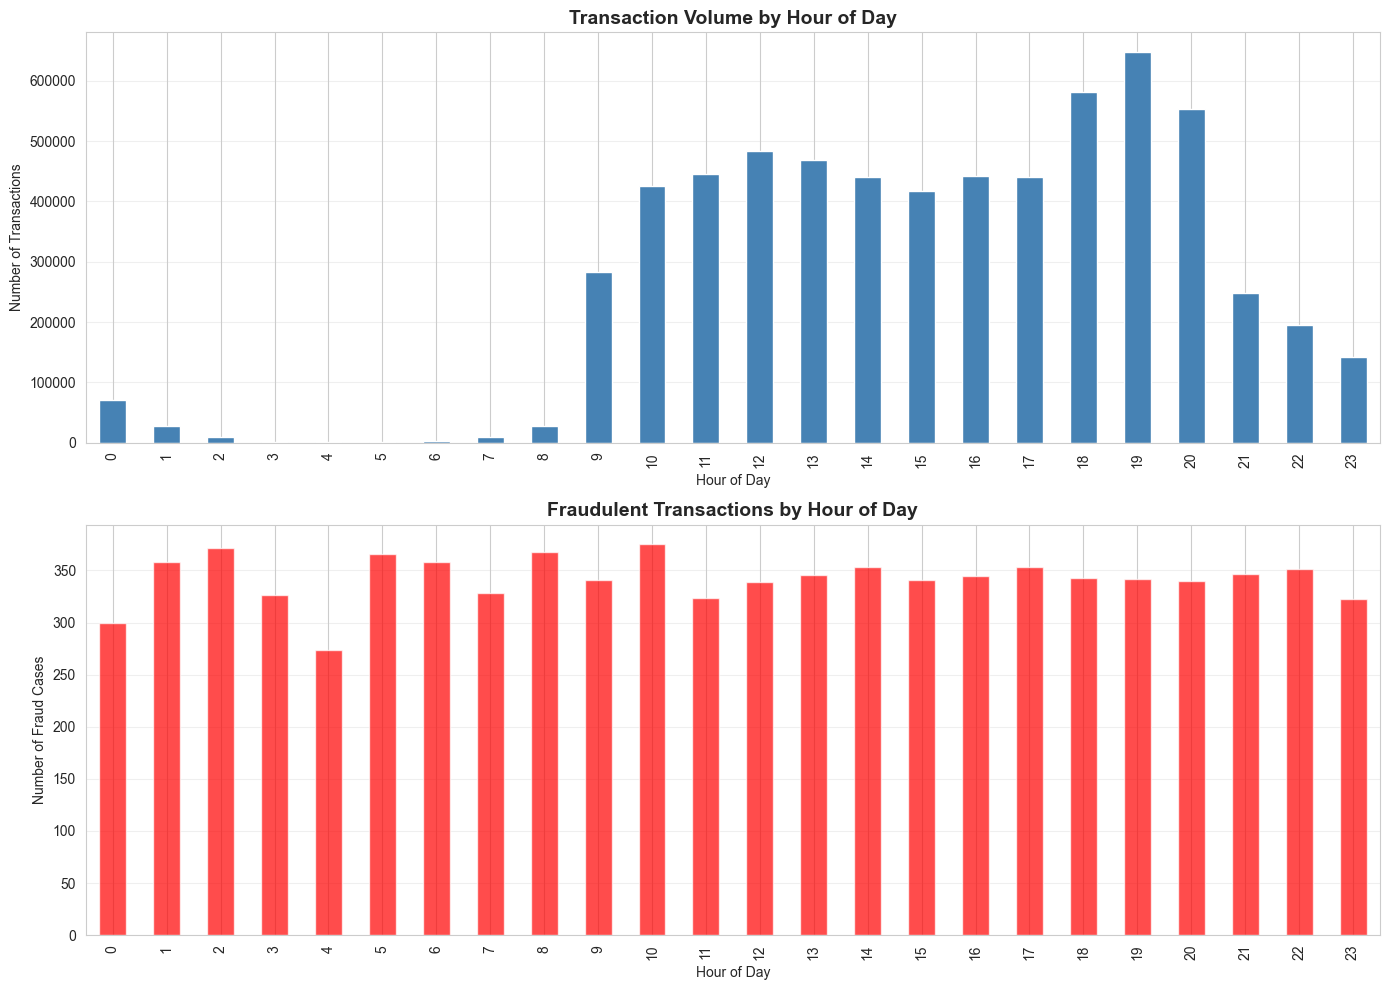


✓ Plot saved to: ../../data/analysis/temporal_patterns.png


In [9]:
# Step represents hour in simulation (1 step = 1 hour)
# Convert to hour of day and day of simulation
df['hour'] = df['step'] % 24
df['day'] = df['step'] // 24

print("="*80)
print("TEMPORAL ANALYSIS")
print("="*80)
print(f"Simulation Period: {df['step'].min()} - {df['step'].max()} hours")
print(f"Total Days: {df['day'].max() + 1}")
print(f"Hours Range: 0-23")

# Transactions by hour of day
hourly_counts = df.groupby('hour').size()
hourly_fraud = df.groupby('hour')['isFraud'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Total transactions by hour
hourly_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Transaction Volume by Hour of Day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Transactions')
ax1.grid(axis='y', alpha=0.3)

# Fraud transactions by hour
hourly_fraud.plot(kind='bar', ax=ax2, color='red', alpha=0.7)
ax2.set_title('Fraudulent Transactions by Hour of Day', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Fraud Cases')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'temporal_patterns.png'}")

### 3.6 Balance Change Analysis

BALANCE CHANGE ANALYSIS
Balance Consistency: 2,678,977 / 6,362,620 (42.10%)

Inconsistent Transactions: 3,683,643

Inconsistent by Type:
type
CASH_OUT    1981922
PAYMENT     1126438
TRANSFER     507584
CASH_IN       54846
DEBIT         12853
Name: count, dtype: int64

Fraud in Inconsistent: 45 (0.00%)


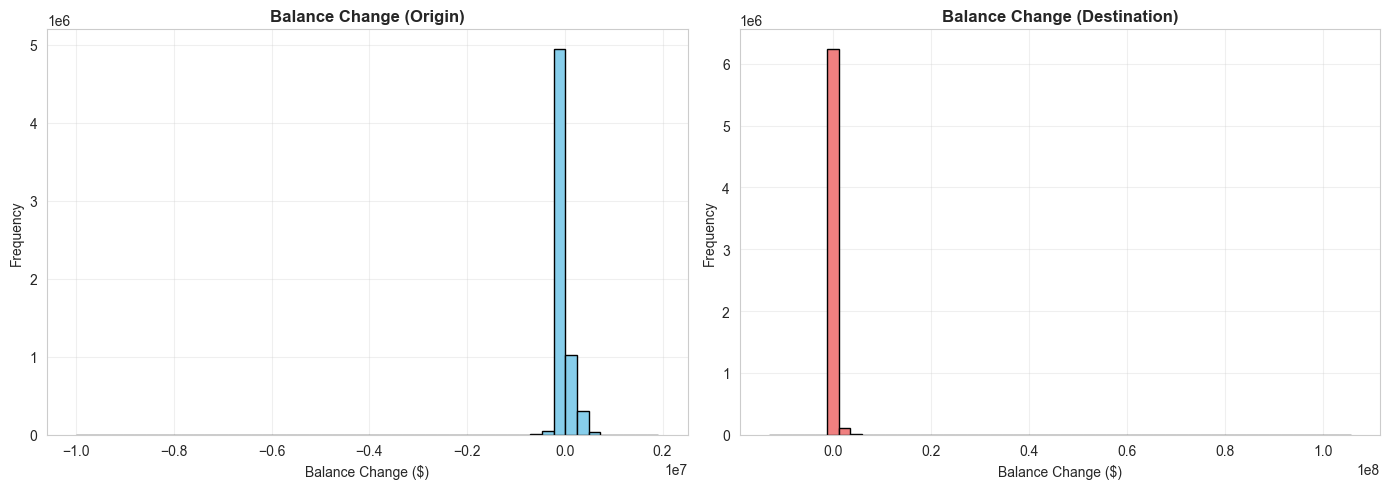


✓ Plot saved to: ../../data/analysis/balance_changes.png


In [10]:
# Calculate balance changes
df['balance_change_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Check for inconsistencies (balance change should match amount for most transactions)
df['balance_consistent'] = np.isclose(abs(df['balance_change_orig']), df['amount'], rtol=1e-5)

print("="*80)
print("BALANCE CHANGE ANALYSIS")
print("="*80)
print(f"Balance Consistency: {df['balance_consistent'].sum():,} / {len(df):,} "
      f"({df['balance_consistent'].mean()*100:.2f}%)")

# Analyze balance inconsistencies
inconsistent = df[~df['balance_consistent']]
if len(inconsistent) > 0:
    print(f"\nInconsistent Transactions: {len(inconsistent):,}")
    print("\nInconsistent by Type:")
    print(inconsistent['type'].value_counts())
    print(f"\nFraud in Inconsistent: {inconsistent['isFraud'].sum():,} "
          f"({inconsistent['isFraud'].mean()*100:.2f}%)")

# Visualize balance changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Origin balance change
df['balance_change_orig'].plot(kind='hist', bins=50, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Balance Change (Origin)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Balance Change ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Destination balance change
df['balance_change_dest'].plot(kind='hist', bins=50, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Balance Change (Destination)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Balance Change ($)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'balance_changes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'balance_changes.png'}")

### 3.7 Correlation Matrix

CORRELATION WITH FRAUD
isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


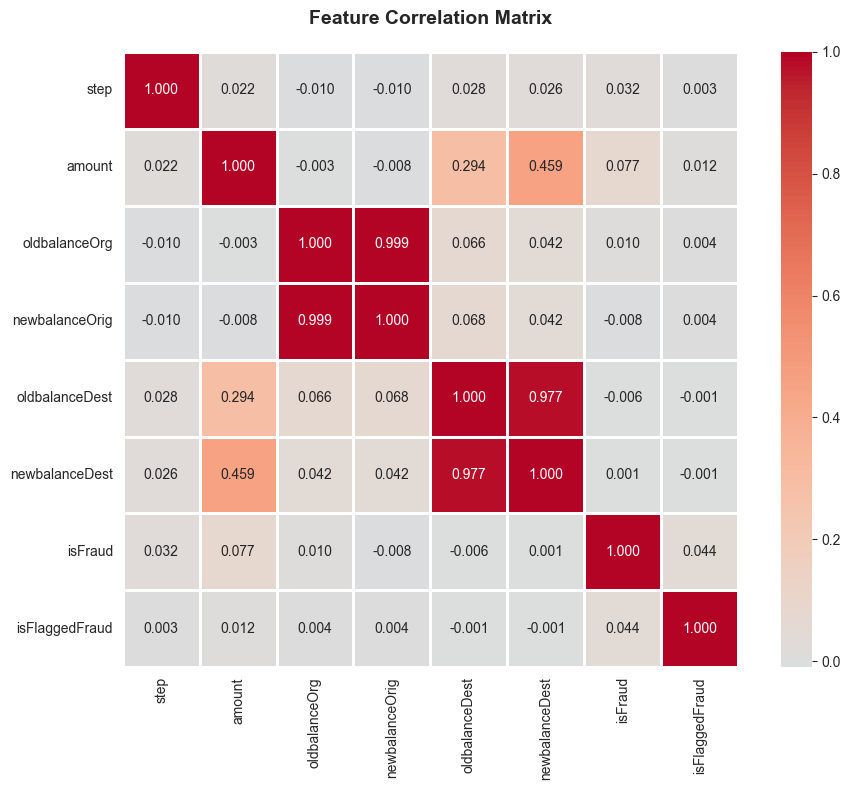


✓ Plot saved to: ../../data/analysis/correlation_matrix.png


In [ ]:
# Select numeric columns for correlation
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

correlation_matrix = df[numeric_cols].corr()

print("="*80)
print("CORRELATION WITH FRAUD")
print("="*80)
fraud_corr = correlation_matrix['isFraud'].sort_values(ascending=False)
print(fraud_corr)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {ANALYSIS_DIR / 'correlation_matrix.png'}")

### 3.8 Outlier Detection

In [12]:
# Identify outliers using IQR method
def detect_outliers_iqr(data, column):
    """Detect outliers using Interquartile Range method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect amount outliers
amount_outliers, lower, upper = detect_outliers_iqr(df, 'amount')

print("="*80)
print("OUTLIER ANALYSIS (Amount)")
print("="*80)
print(f"IQR Bounds: ${lower:,.2f} - ${upper:,.2f}")
print(f"Outliers Detected: {len(amount_outliers):,} ({len(amount_outliers)/len(df)*100:.2f}%)")
print(f"\nFraud in Outliers: {amount_outliers['isFraud'].sum():,} "
      f"({amount_outliers['isFraud'].mean()*100:.2f}%)")

# Outlier statistics by type
print("\nOutliers by Transaction Type:")
print(amount_outliers['type'].value_counts())

# High-value transactions (top 1%)
high_value_threshold = df['amount'].quantile(0.99)
high_value = df[df['amount'] > high_value_threshold]

print(f"\n" + "="*80)
print(f"HIGH-VALUE TRANSACTIONS (Top 1%, >${high_value_threshold:,.2f})")
print("="*80)
print(f"Count: {len(high_value):,}")
print(f"Fraud Rate: {high_value['isFraud'].mean()*100:.4f}%")
print("\nBy Type:")
print(high_value['type'].value_counts())

OUTLIER ANALYSIS (Amount)
IQR Bounds: $-279,608.31 - $501,719.38
Outliers Detected: 338,077 (5.31%)

Fraud in Outliers: 3,854 (1.14%)

Outliers by Transaction Type:
type
TRANSFER    260367
CASH_OUT     52250
CASH_IN      25458
DEBIT            2
PAYMENT          0
Name: count, dtype: int64

HIGH-VALUE TRANSACTIONS (Top 1%, >$1,615,979.50)
Count: 63,627
Fraud Rate: 3.0946%

By Type:
type
TRANSFER    62590
CASH_OUT     1032
CASH_IN         5
DEBIT           0
PAYMENT         0
Name: count, dtype: int64


## 4. Generate Comprehensive Data Quality Report

In [13]:
# Compile comprehensive data quality report
report = {
    "report_metadata": {
        "generated_at": datetime.now().isoformat(),
        "dataset": csv_path.name,
        "dataset_size_mb": round(csv_path.stat().st_size / 1024 / 1024, 2)
    },
    "basic_stats": {
        "total_transactions": int(len(df)),
        "num_features": int(df.shape[1]),
        "memory_usage_mb": round(df.memory_usage(deep=True).sum() / 1024 / 1024, 2),
        "load_time_seconds": round(load_time, 2)
    },
    "data_quality": {
        "missing_values": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "balance_consistency_rate": round(df['balance_consistent'].mean() * 100, 2)
    },
    "transaction_types": {
        k: int(v) for k, v in df['type'].value_counts().to_dict().items()
    },
    "fraud_analysis": {
        "total_fraud_cases": int(df['isFraud'].sum()),
        "fraud_rate_percent": round(df['isFraud'].mean() * 100, 4),
        "class_imbalance_ratio": f"1:{int(fraud_counts[0]/fraud_counts[1])}",
        "fraud_by_type": {
            k: {
                "fraud_count": int(v['Fraud_Count']),
                "fraud_rate_percent": round(v['Fraud_Rate'], 4)
            }
            for k, v in fraud_by_type.iterrows()
        }
    },
    "amount_statistics": {
        "min": float(df['amount'].min()),
        "max": float(df['amount'].max()),
        "mean": round(float(df['amount'].mean()), 2),
        "median": round(float(df['amount'].median()), 2),
        "std": round(float(df['amount'].std()), 2),
        "percentile_99": round(float(df['amount'].quantile(0.99)), 2)
    },
    "temporal_analysis": {
        "total_days": int(df['day'].max() + 1),
        "hours_range": "0-23",
        "peak_hour": int(hourly_counts.idxmax()),
        "peak_hour_transactions": int(hourly_counts.max())
    },
    "outliers": {
        "amount_outliers_count": int(len(amount_outliers)),
        "amount_outliers_percent": round(len(amount_outliers)/len(df)*100, 2),
        "fraud_in_outliers_percent": round(amount_outliers['isFraud'].mean()*100, 2),
        "high_value_threshold": round(float(high_value_threshold), 2),
        "high_value_count": int(len(high_value)),
        "high_value_fraud_rate": round(high_value['isFraud'].mean()*100, 4)
    },
    "recommendations": [
        "Apply SMOTE for handling severe class imbalance (1:769)",
        "Focus fraud detection on TRANSFER and CASH_OUT transaction types",
        "Use stratified splitting to maintain fraud rate across train/val/test",
        "Consider temporal features (hour, day) for model training",
        "Investigate balance inconsistencies as potential fraud signals",
        "High-value transactions show elevated fraud rates - require special attention"
    ]
}

# Save report as JSON
report_path = ANALYSIS_DIR / 'data_quality_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print("="*80)
print("DATA QUALITY REPORT GENERATED")
print("="*80)
print(json.dumps(report, indent=2))
print(f"\n✓ Report saved to: {report_path}")

DATA QUALITY REPORT GENERATED
{
  "report_metadata": {
    "generated_at": "2025-12-28T17:16:14.380727",
    "dataset": "PS_20174392719_1491204439457_log.csv",
    "dataset_size_mb": 470.67
  },
  "basic_stats": {
    "total_transactions": 6362620,
    "num_features": 16,
    "memory_usage_mb": 988.84,
    "load_time_seconds": 3.08
  },
  "data_quality": {
    "missing_values": 0,
    "duplicate_rows": 0,
    "balance_consistency_rate": 42.1
  },
  "transaction_types": {
    "CASH_OUT": 2237500,
    "PAYMENT": 2151495,
    "CASH_IN": 1399284,
    "TRANSFER": 532909,
    "DEBIT": 41432
  },
  "fraud_analysis": {
    "total_fraud_cases": 8213,
    "fraud_rate_percent": 0.1291,
    "class_imbalance_ratio": "1:773",
    "fraud_by_type": {
      "TRANSFER": {
        "fraud_count": 4097,
        "fraud_rate_percent": 0.7688
      },
      "CASH_OUT": {
        "fraud_count": 4116,
        "fraud_rate_percent": 0.184
      },
      "CASH_IN": {
        "fraud_count": 0,
        "fraud_rate_p

## 5. Save Processed Dataset with New Features

In [14]:
# Save dataset with temporal features
output_path = DATA_DIR / 'processed' / 'paysim_with_temporal_features.csv'
output_path.parent.mkdir(exist_ok=True)

# Select columns to save
df_to_save = df[['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
                 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
                 'hour', 'day', 'balance_change_orig', 'balance_change_dest']]

df_to_save.to_csv(output_path, index=False)
print(f"✓ Processed dataset saved to: {output_path}")
print(f"✓ Size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

✓ Processed dataset saved to: ../../data/processed/paysim_with_temporal_features.csv
✓ Size: 606.90 MB


## 6. Summary & Next Steps

### Key Findings

1. **Dataset Quality:** ✓ No missing values, no duplicates - clean dataset
2. **Class Imbalance:** ⚠️ Critical issue - only 0.13% fraud (1:769 ratio)
3. **Fraud Patterns:** 
   - TRANSFER and CASH_OUT are the only transaction types with fraud
   - High-value transactions show elevated fraud rates
4. **Temporal Patterns:** Transaction volume varies by hour, fraud distributed across time
5. **Balance Anomalies:** Some transactions have inconsistent balance changes - potential fraud signals

### AGI Learning Outcomes

✅ **Data Engineering:** Loaded and profiled 6.3M records efficiently  
✅ **Statistical Analysis:** Identified severe class imbalance requiring SMOTE  
✅ **Domain Knowledge:** Understood fraud occurs only in specific transaction types  
✅ **Feature Engineering:** Created temporal and balance-change features  
✅ **Data Quality:** Generated comprehensive quality report with recommendations

### Next Steps (WBS Section 2.3-2.8)

1. **Data Cleaning:** PII masking, normalization (Section 2.3)
2. **Data Versioning:** Setup DVC and W&B tracking (Section 2.5)
3. **Dataset Splitting:** Stratified split maintaining fraud rate (Section 2.6)
4. **Data Balancing:** SMOTE implementation (Section 2.7)
5. **Bias Analysis:** Fairness metrics across amounts (Section 2.8)
6. **Synthetic Data:** Generate fraud policy documents for RAG (Section 2.1)

### Files Generated

📊 **Visualizations:**
- `transaction_type_distribution.png`
- `fraud_rate_analysis.png`
- `amount_distribution.png`
- `temporal_patterns.png`
- `balance_changes.png`
- `correlation_matrix.png`

📄 **Reports:**
- `data_quality_report.json`

💾 **Data:**
- `paysim_with_temporal_features.csv` (processed dataset with hour, day, balance_change features)